In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 985s 6us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

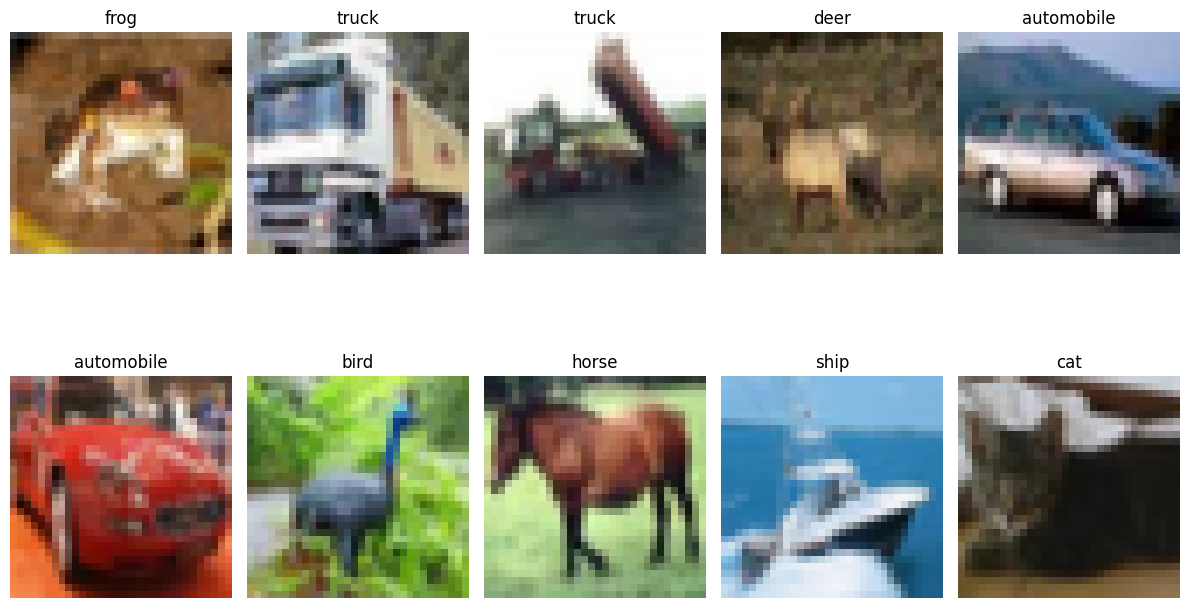

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

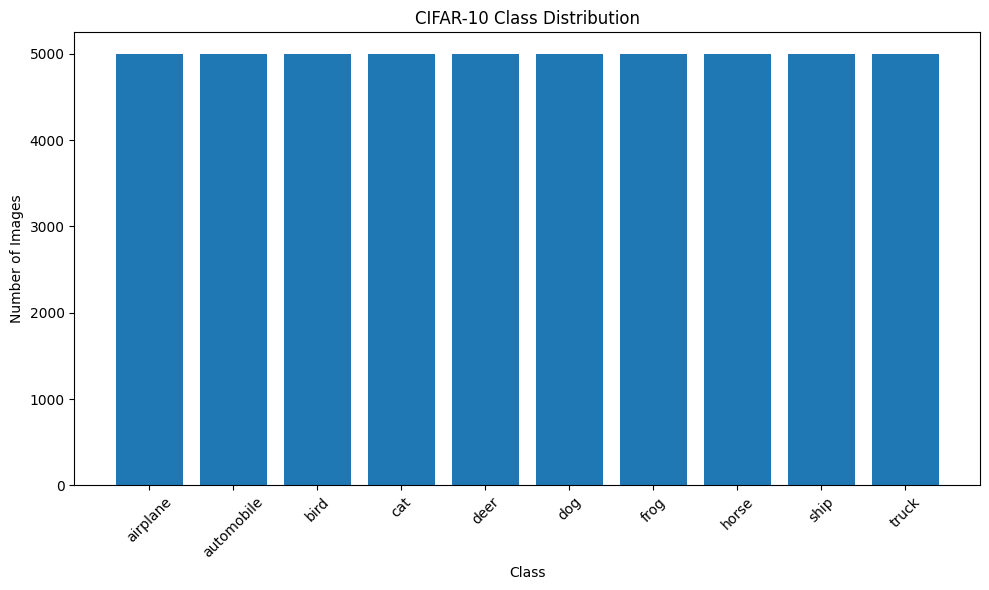

In [ ]:
class_counts = np.bincount(y_train_flat)

plt.figure(figsize=(10, 6))

plt.bar(class_names, class_counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [ ]:
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
input_image = x_train[0:1]

kernel_sizes = [3, 5, 7]

for kernel_size in kernel_sizes:

    conv_layer = layers.Conv2D(
        filters=8,
        kernel_size=(kernel_size, kernel_size),
        strides=1,
        padding="valid",
        activation=None
    )

    output = conv_layer(input_image)

    print(
        f"Kernel {kernel_size}x{kernel_size} -> "
        f"Output shape: {output.shape}"
    )

Kernel 3x3 -> Output shape: (1, 30, 30, 8)
Kernel 5x5 -> Output shape: (1, 28, 28, 8)
Kernel 7x7 -> Output shape: (1, 26, 26, 8)


In [ ]:
conv_layer = layers.Conv2D(
    filters=8,
    kernel_size=3,
    padding="valid",
    activation="relu"
)

feature_maps = conv_layer(input_image)

print(feature_maps.shape)

(1, 30, 30, 8)


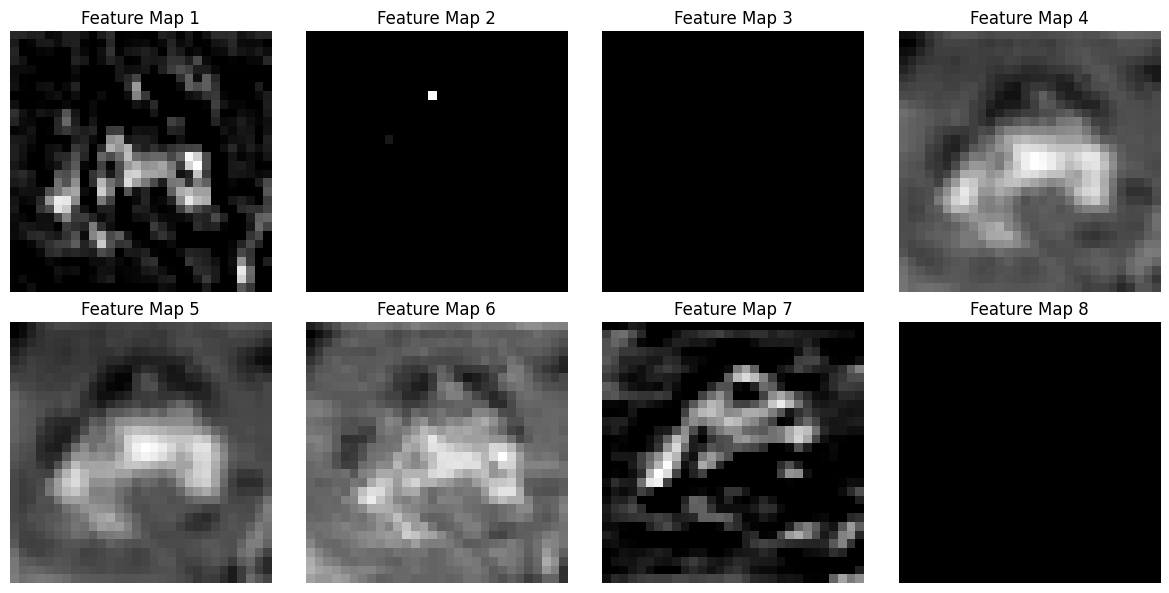

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    plt.imshow(feature_maps[0, :, :, i], cmap="gray")
    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("feature_maps_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
for stride in [1, 2]:

    conv_layer = layers.Conv2D(
        filters=8,
        kernel_size=3,
        strides=stride,
        padding="valid"
    )

    output = conv_layer(input_image)

    print(
        f"Stride {stride}: {output.shape}"
    )

Stride 1: (1, 30, 30, 8)
Stride 2: (1, 15, 15, 8)


In [ ]:
for padding in ["same", "valid"]:

    conv_layer = layers.Conv2D(
        filters=8,
        kernel_size=3,
        strides=1,
        padding=padding
    )

    output = conv_layer(input_image)

    print(
        f"Padding {padding}: {output.shape}"
    )

Padding same: (1, 32, 32, 8)
Padding valid: (1, 30, 30, 8)


In [ ]:
sample = x_train[0:1]

max_pool = layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

avg_pool = layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

max_output = max_pool(sample)
avg_output = avg_pool(sample)

print("Input:", sample.shape)
print("Max Pooling:", max_output.shape)
print("Average Pooling:", avg_output.shape)

Input: (1, 32, 32, 3)
Max Pooling: (1, 16, 16, 3)
Average Pooling: (1, 16, 16, 3)


In [ ]:
model = keras.Sequential([

    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        10,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,362 (235.79 KB)

 Trainable params: 60,362 (235.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4923 - loss: 1.4300 - val_accuracy: 0.5930 - val_loss: 1.1664
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6265 - loss: 1.0707 - val_accuracy: 0.6536 - val_loss: 1.0109
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6716 - loss: 0.9476 - val_accuracy: 0.6718 - val_loss: 0.9662
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6978 - loss: 0.8694 - val_accuracy: 0.6900 - val_loss: 0.9168
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7206 - loss: 0.8056 - val_accuracy: 0.6622 - val_loss: 0.9820
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7399 - loss: 0.7479 - val_accuracy: 0.6976 - val_loss: 0.9125
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7544 - loss: 0.7058 - val_accuracy: 0.7126 - val_loss: 0.8621
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7710 - loss: 0.6613 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 1.1737619638442993
Test Accuracy: 0.676800012588501


In [ ]:
print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

Test Accuracy: 67.68%


In [ ]:
y_prob = model.predict(
    x_test,
    verbose=1
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1-score : {f1 * 100:.2f}%")

Accuracy : 67.68%
Precision: 69.41%
Recall   : 67.68%
F1-score : 68.02%


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.79      0.60      0.68      1000
  automobile       0.83      0.81      0.82      1000
        bird       0.51      0.65      0.57      1000
         cat       0.43      0.60      0.50      1000
        deer       0.66      0.58      0.61      1000
         dog       0.66      0.49      0.57      1000
        frog       0.75      0.73      0.74      1000
       horse       0.76      0.72      0.74      1000
        ship       0.79      0.81      0.80      1000
       truck       0.77      0.79      0.78      1000

    accuracy                           0.68     10000
   macro avg       0.69      0.68      0.68     10000
weighted avg       0.69      0.68      0.68     10000



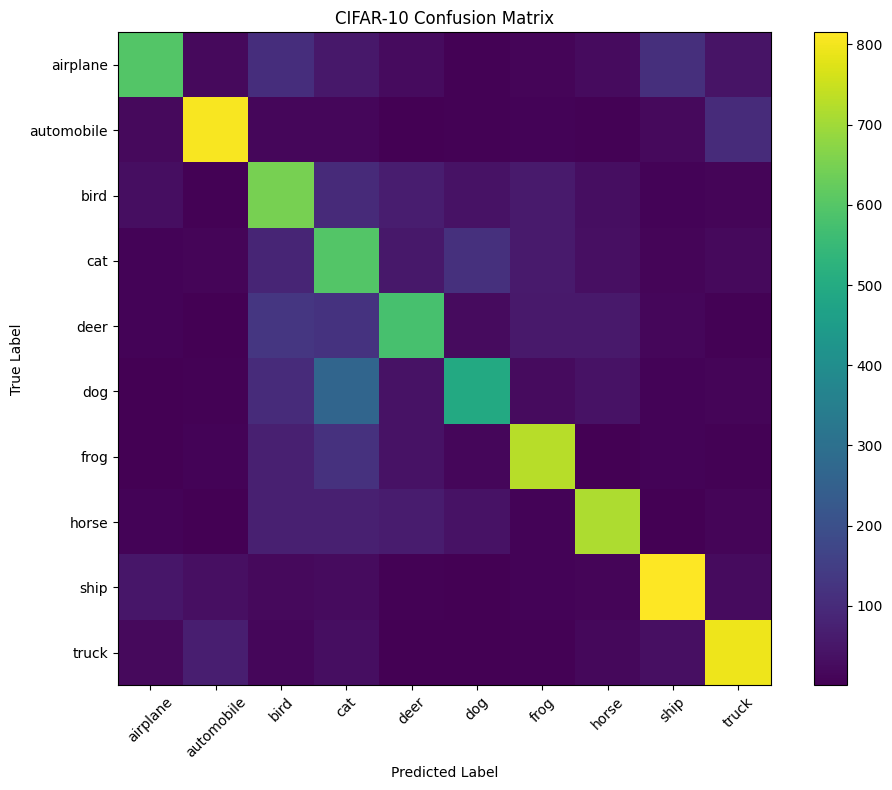

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title("CIFAR-10 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(10),
    class_names,
    rotation=45
)

plt.yticks(
    range(10),
    class_names
)

plt.colorbar()

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

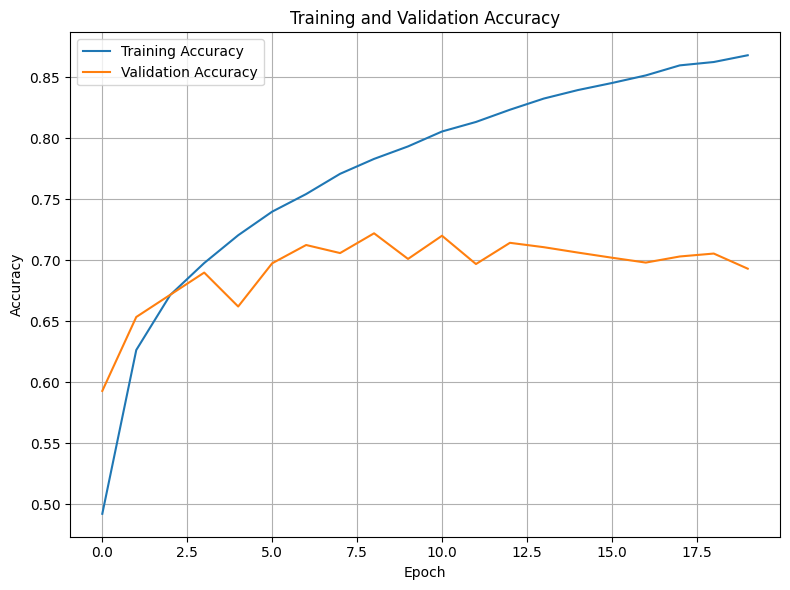

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

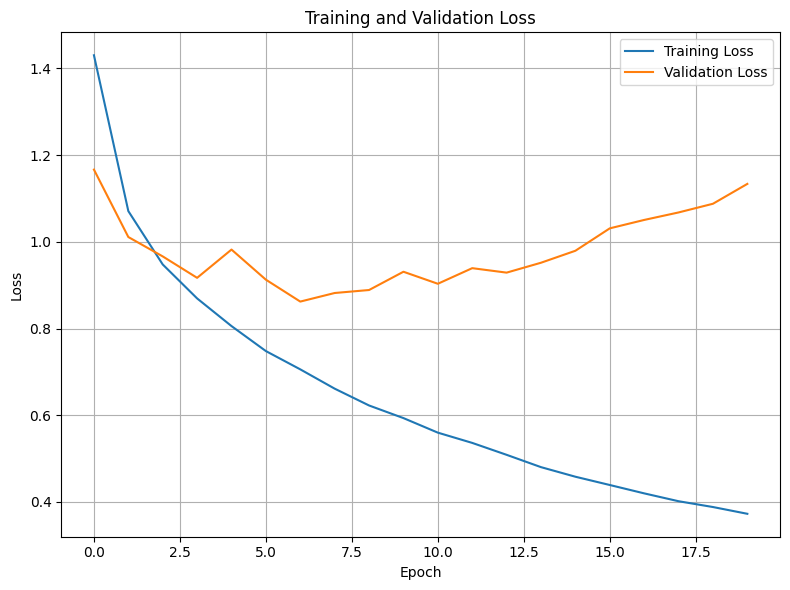

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
feature_model = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

print(feature_model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
sample_image = x_test[0:1]

feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)

print("Feature map shape:", feature_maps.shape)

Feature map shape: (1, 32, 32, 32)


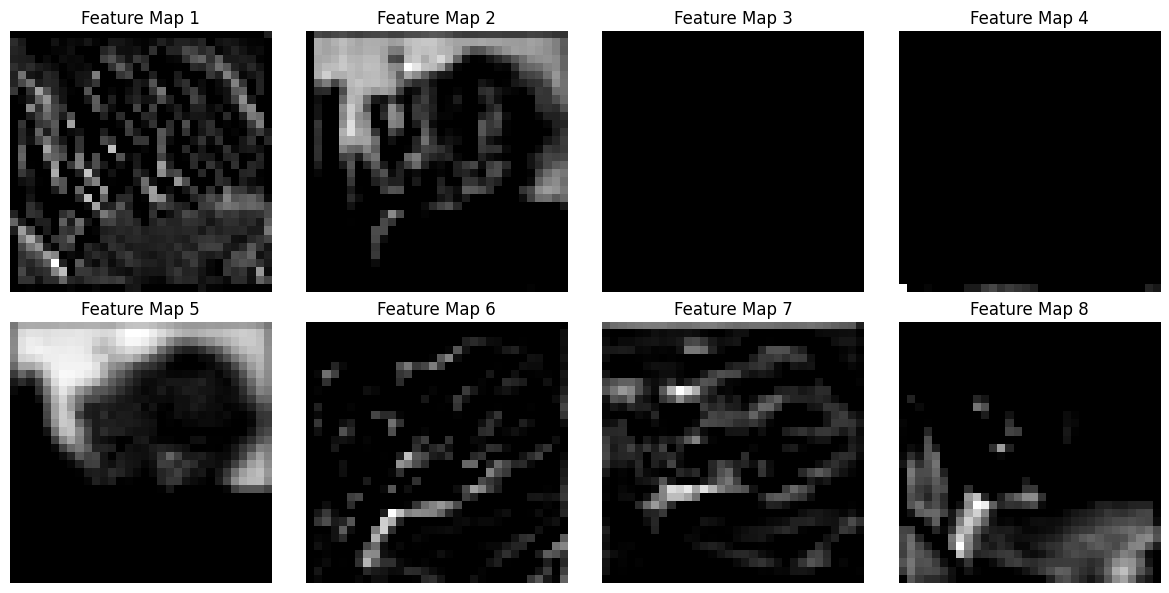

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        feature_maps[0, :, :, i],
        cmap="gray"
    )

    plt.title(f"Feature Map {i + 1}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "first_layer_feature_maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,088 (707.38 KB)

 Trainable params: 60,362 (235.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 120,726 (471.59 KB)

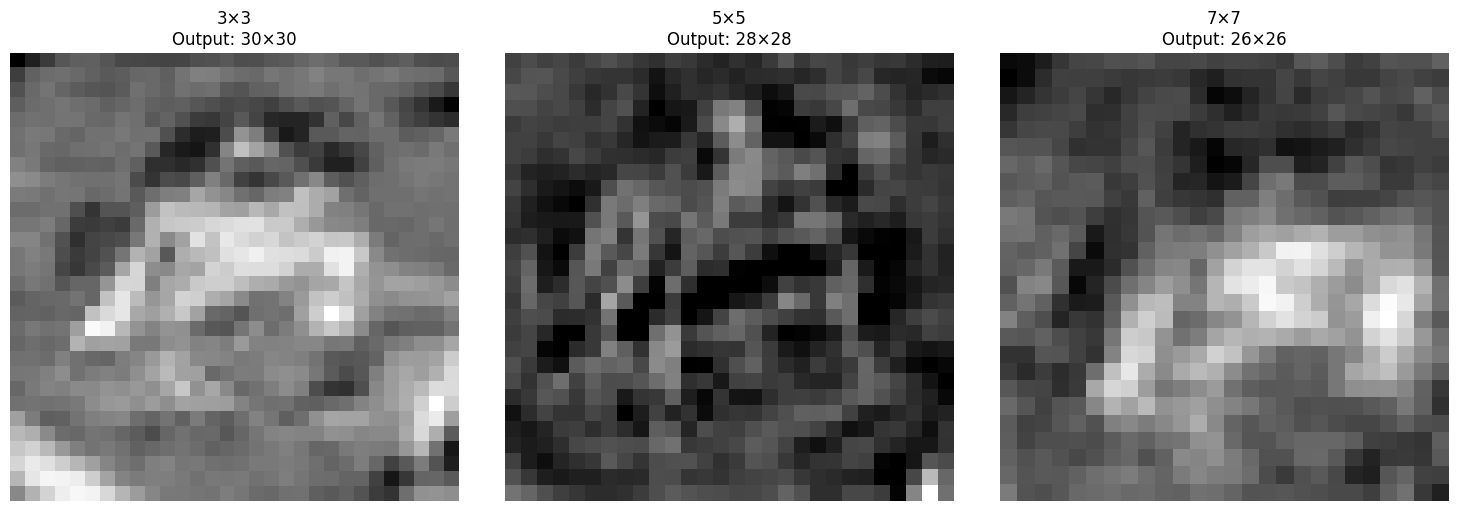

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow import keras

# Load and normalize x_train to make it available in this cell
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0

kernel_sizes = [3, 5, 7]

plt.figure(figsize=(15, 5))

for i, kernel_size in enumerate(kernel_sizes):

    conv_layer = layers.Conv2D(
        filters=8,
        kernel_size=(kernel_size, kernel_size),
        strides=1,
        padding="valid",
        activation="relu"
    )

    output = conv_layer(x_train[0:1])

    # Display the first feature map
    plt.subplot(1, 3, i + 1)
    plt.imshow(output[0, :, :, 0], cmap="gray")

    plt.title(
        f"{kernel_size}×{kernel_size}\n"
        f"Output: {output.shape[1]}×{output.shape[2]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "feature_maps_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Kernel 3x3 -> Output: 30x30
Kernel 5x5 -> Output: 28x28
Kernel 7x7 -> Output: 26x26


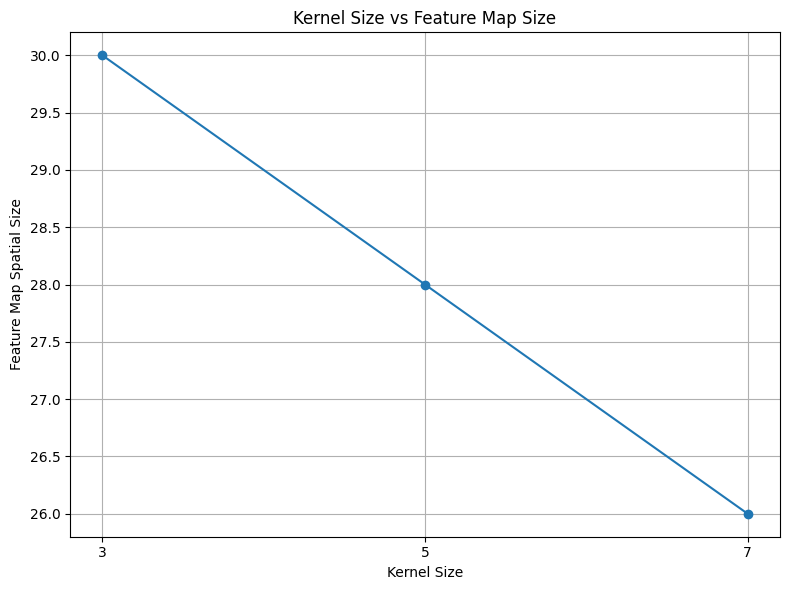

In [ ]:
kernel_sizes = [3, 5, 7]
output_sizes = []

sample_image = x_train[0:1]

for kernel_size in kernel_sizes:

    conv_layer = layers.Conv2D(
        filters=8,
        kernel_size=(kernel_size, kernel_size),
        strides=1,
        padding="valid"
    )

    output = conv_layer(sample_image)

    output_sizes.append(output.shape[1])

    print(
        f"Kernel {kernel_size}x{kernel_size} "
        f"-> Output: {output.shape[1]}x{output.shape[2]}"
    )


plt.figure(figsize=(8, 6))

plt.plot(
    kernel_sizes,
    output_sizes,
    marker="o"
)

plt.xlabel("Kernel Size")
plt.ylabel("Feature Map Spatial Size")
plt.title("Kernel Size vs Feature Map Size")

plt.xticks(kernel_sizes)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "kernel_vs_featuremap_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
sample_image = x_train[0:1]

results = {}

# Stride = 1
layer = layers.Conv2D(
    filters=8,
    kernel_size=3,
    strides=1,
    padding="valid"
)

output = layer(sample_image)

results["Stride 1"] = (
    output.shape[1],
    output.shape[2]
)


# Stride = 2
layer = layers.Conv2D(
    filters=8,
    kernel_size=3,
    strides=2,
    padding="valid"
)

output = layer(sample_image)

results["Stride 2"] = (
    output.shape[1],
    output.shape[2]
)


# Same padding
layer = layers.Conv2D(
    filters=8,
    kernel_size=3,
    strides=1,
    padding="same"
)

output = layer(sample_image)

results["Same Padding"] = (
    output.shape[1],
    output.shape[2]
)


# Valid padding
layer = layers.Conv2D(
    filters=8,
    kernel_size=3,
    strides=1,
    padding="valid"
)

output = layer(sample_image)

results["Valid Padding"] = (
    output.shape[1],
    output.shape[2]
)


print("Results:")

for name, size in results.items():
    print(f"{name}: {size[0]} x {size[1]}")

Results:
Stride 1: 30 x 30
Stride 2: 15 x 15
Same Padding: 32 x 32
Valid Padding: 30 x 30


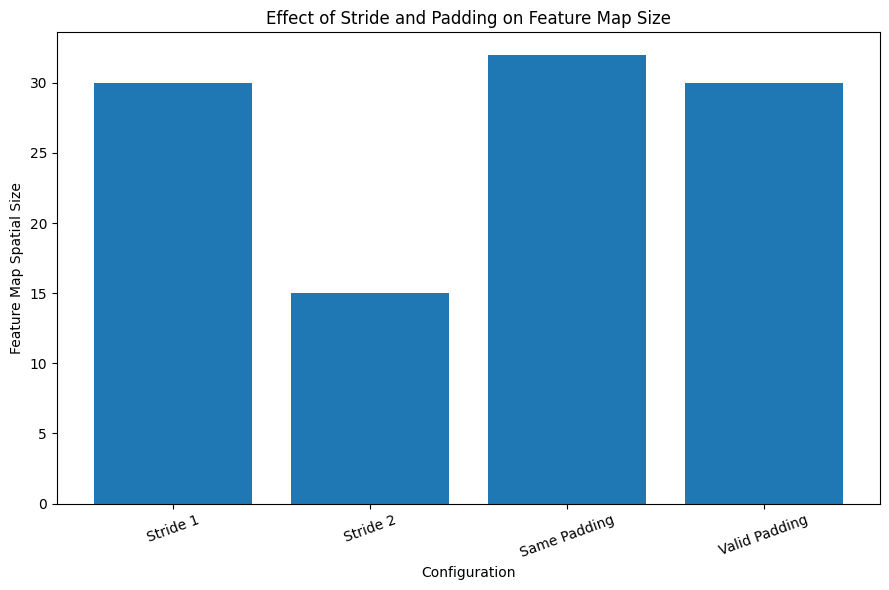

In [ ]:
labels = list(results.keys())

sizes = [
    results[label][0]
    for label in labels
]


plt.figure(figsize=(9, 6))

plt.bar(
    labels,
    sizes
)

plt.xlabel("Configuration")
plt.ylabel("Feature Map Spatial Size")
plt.title("Effect of Stride and Padding on Feature Map Size")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "stride_padding_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Make sure the model has been called
_ = model(x_test[0:1])

feature_model = keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

In [ ]:
sample_image = x_test[0:1]

feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)

print("Feature map shape:", feature_maps.shape)

Feature map shape: (1, 32, 32, 32)


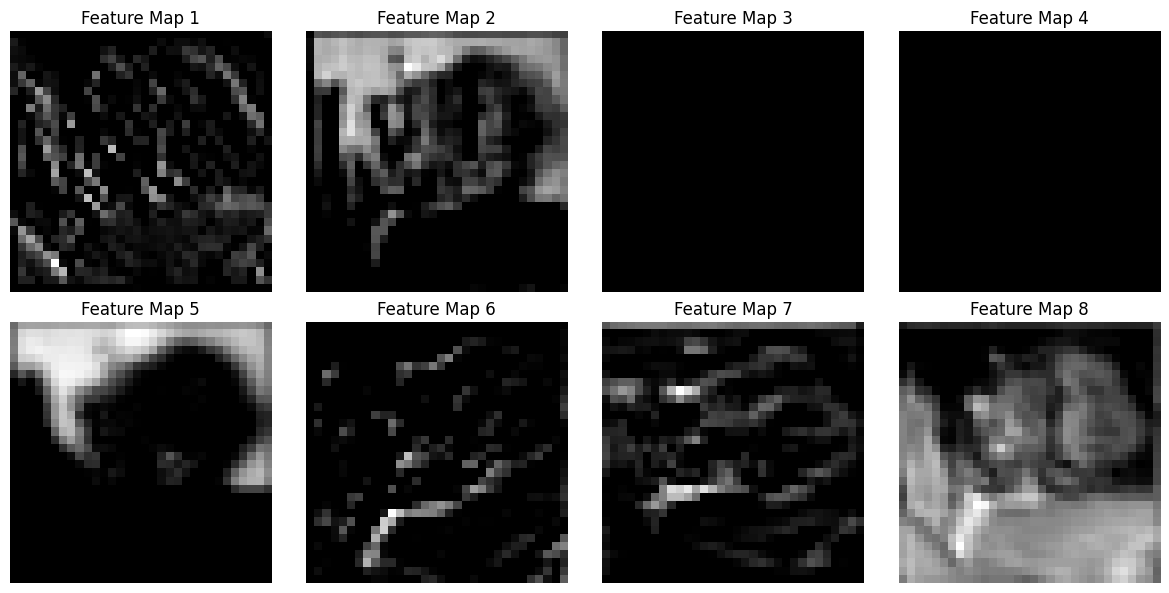

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        feature_maps[0, :, :, i],
        cmap="gray"
    )

    plt.title(f"Feature Map {i + 1}")

    plt.axis("off")


plt.tight_layout()

plt.savefig(
    "first_layer_feature_maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Take one test image and convert it to float32
sample_image = x_test[0:1].astype("float32")

# Normalize pixel values from 0-255 to 0-1
sample_image = sample_image / 255.0

# Create convolution layer
conv_layer = layers.Conv2D(
    filters=16,
    kernel_size=3,
    padding="same",
    activation="relu"
)

# Apply convolution
conv_output = conv_layer(sample_image)

print("Input shape:", sample_image.shape)
print("Convolution output:", conv_output.shape)

Input shape: (1, 32, 32, 3)
Convolution output: (1, 32, 32, 16)


In [ ]:
max_pool = layers.MaxPooling2D(
    pool_size=(2, 2),
    strides=2
)

avg_pool = layers.AveragePooling2D(
    pool_size=(2, 2),
    strides=2
)

max_output = max_pool(conv_output)
avg_output = avg_pool(conv_output)

print("Max pooling:", max_output.shape)
print("Average pooling:", avg_output.shape)

Max pooling: (1, 16, 16, 16)
Average pooling: (1, 16, 16, 16)


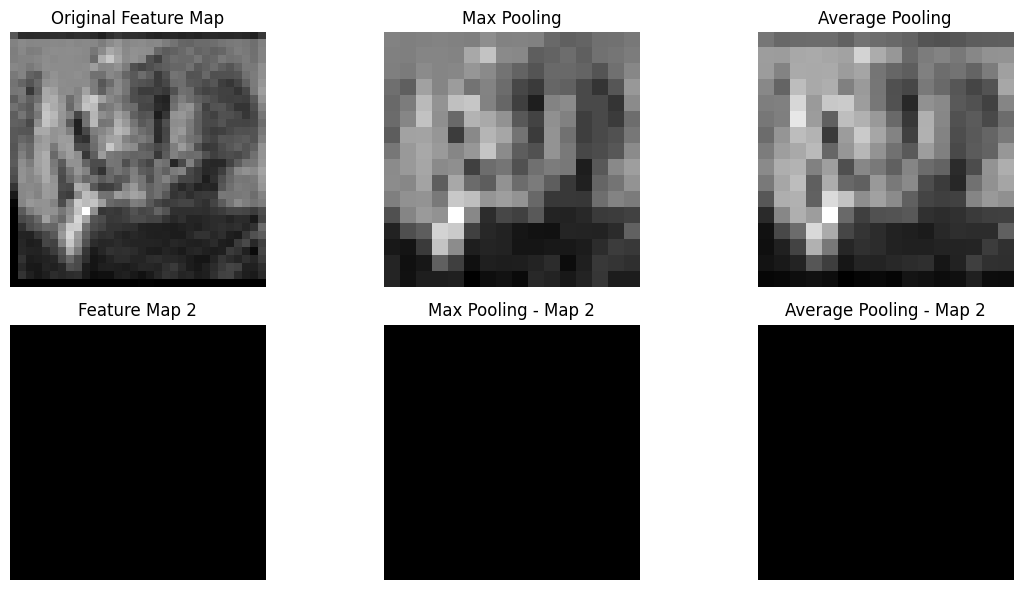

In [ ]:
plt.figure(figsize=(12, 6))

# Original feature map
plt.subplot(2, 3, 1)
plt.imshow(
    conv_output[0, :, :, 0],
    cmap="gray"
)
plt.title("Original Feature Map")
plt.axis("off")


# Max Pooling
plt.subplot(2, 3, 2)
plt.imshow(
    max_output[0, :, :, 0],
    cmap="gray"
)
plt.title("Max Pooling")
plt.axis("off")


# Average Pooling
plt.subplot(2, 3, 3)
plt.imshow(
    avg_output[0, :, :, 0],
    cmap="gray"
)
plt.title("Average Pooling")
plt.axis("off")


# Another feature map
plt.subplot(2, 3, 4)
plt.imshow(
    conv_output[0, :, :, 1],
    cmap="gray"
)
plt.title("Feature Map 2")
plt.axis("off")


plt.subplot(2, 3, 5)
plt.imshow(
    max_output[0, :, :, 1],
    cmap="gray"
)
plt.title("Max Pooling - Map 2")
plt.axis("off")


plt.subplot(2, 3, 6)
plt.imshow(
    avg_output[0, :, :, 1],
    cmap="gray"
)
plt.title("Average Pooling - Map 2")
plt.axis("off")


plt.tight_layout()

plt.savefig(
    "maxpool_vs_avgpool_featuremaps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
def build_pooling_model(pooling_type):

    model = keras.Sequential([

        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        pooling_type((2, 2)),

        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        pooling_type((2, 2)),

        layers.Flatten(),

        layers.Dense(
            10,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
max_model = build_pooling_model(
    layers.MaxPooling2D
)

max_history = max_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4881 - loss: 1.4513 - val_accuracy: 0.5670 - val_loss: 1.2288
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6195 - loss: 1.0903 - val_accuracy: 0.6616 - val_loss: 1.0025
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6705 - loss: 0.9539 - val_accuracy: 0.6758 - val_loss: 0.9489
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7008 - loss: 0.8667 - val_accuracy: 0.6832 - val_loss: 0.9424
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7218 - loss: 0.8046 - val_accuracy: 0.7018 - val_loss: 0.8878
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7398 - loss: 0.7505 - val_accuracy: 0.7092 - val_loss: 0.8658
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7558 - loss: 0.7105 - val_accuracy: 0.7014 - val_loss: 0.9119
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7665 - loss: 0.6731 -

In [ ]:
max_loss, max_accuracy = max_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(
    f"Max Pooling Accuracy: "
    f"{max_accuracy * 100:.2f}%"
)

Max Pooling Accuracy: 48.91%


In [ ]:
avg_model = build_pooling_model(
    layers.AveragePooling2D
)

avg_history = avg_model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4602 - loss: 1.5190 - val_accuracy: 0.5222 - val_loss: 1.3733
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5760 - loss: 1.2118 - val_accuracy: 0.6136 - val_loss: 1.1139
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6297 - loss: 1.0590 - val_accuracy: 0.6300 - val_loss: 1.0652
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6651 - loss: 0.9723 - val_accuracy: 0.6578 - val_loss: 1.0018
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6851 - loss: 0.9141 - val_accuracy: 0.6666 - val_loss: 0.9683
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7013 - loss: 0.8629 - val_accuracy: 0.6866 - val_loss: 0.9246
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7158 - loss: 0.8215 - val_accuracy: 0.7026 - val_loss: 0.8689
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7296 - loss: 0.7813 -

In [ ]:
avg_loss, avg_accuracy = avg_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(
    f"Average Pooling Accuracy: "
    f"{avg_accuracy * 100:.2f}%"
)

Average Pooling Accuracy: 46.38%


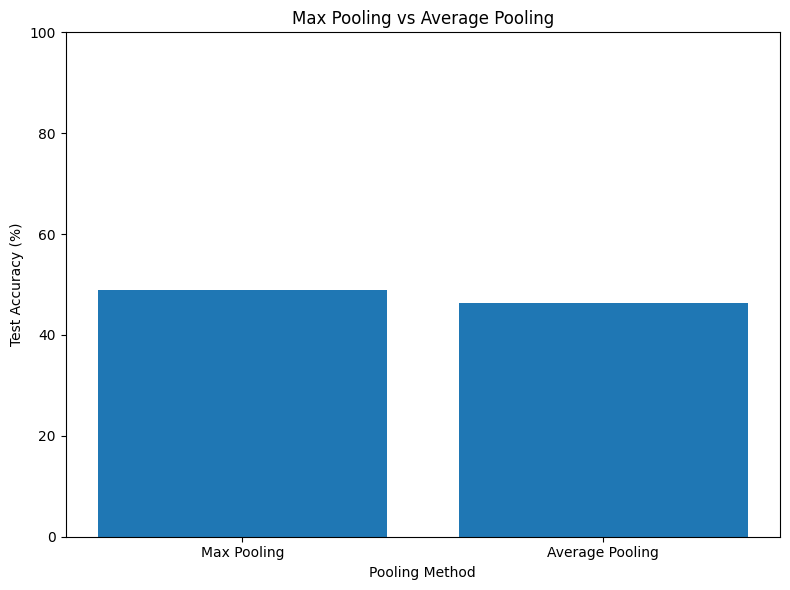

In [ ]:
pooling_methods = [
    "Max Pooling",
    "Average Pooling"
]

pooling_accuracies = [
    max_accuracy * 100,
    avg_accuracy * 100
]


plt.figure(figsize=(8, 6))

plt.bar(
    pooling_methods,
    pooling_accuracies
)

plt.xlabel("Pooling Method")
plt.ylabel("Test Accuracy (%)")
plt.title("Max Pooling vs Average Pooling")

plt.ylim(0, 100)

plt.tight_layout()

plt.savefig(
    "pooling_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy * 100, "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5058 - loss: 344.3752
Test Loss: 344.375244140625
Test Accuracy: 50.58000087738037 %
